In [12]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from matplotlib import pyplot as plt

In [3]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [4]:
# Create data loaders.
train_loader = DataLoader(training_data, batch_size=8)
test_loader = DataLoader(test_data, batch_size=8)

for X, y in test_loader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([8, 1, 28, 28])
Shape of y: torch.Size([8]) torch.int64


In [5]:
images, labels = next(iter(train_loader))

In [6]:
flattened_images = images.view(images.size(0), -1)
flattened_images.shape

torch.Size([8, 784])

In [20]:
X = flattened_images
W = torch.randn(10, 784,requires_grad=True)
B= torch.randn(10,requires_grad=True)
Y = X @ W.T + B

In [22]:
loss = Y.sum()
print(loss.item())

loss.backward()

print(W.grad)
print(B.grad)

-122.30259704589844
tensor([[0.0000, 0.0000, 0.0000,  ..., 0.2745, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.2745, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.2745, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.2745, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.2745, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.2745, 0.0000, 0.0000]])
tensor([8., 8., 8., 8., 8., 8., 8., 8., 8., 8.])


In [14]:
class SimpleANN(nn.Module):
        def __init__(self):
            super(SimpleANN, self).__init__()
            self.flatten = nn.Flatten()
            self.fc1 = nn.Linear(784, 128)
            self.fc2 = nn.Linear(128, 64)
            self.fc3 = nn.Linear(64, 10)

        def forward(self, x):
            x = self.flatten(x)  
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

In [20]:
model = SimpleANN()
criterion = nn.CrossEntropyLoss()
learning_rate = 0.01
loss_history = []
for epoch in range(5):

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Manual Gradient Descent
        with torch.no_grad():
            for param in model.parameters():
                param -= learning_rate * param.grad

        # Zero gradients
        model.zero_grad()

        # Accumulate loss
        total_loss += loss.item()
        loss_history.append(total_loss)

        # Compute accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Epoch {epoch+1} | Avg Loss: {total_loss:.4f} | Accuracy: {accuracy:.2f}%")

    


Epoch 1 | Avg Loss: 5331.0523 | Accuracy: 74.80%
Epoch 2 | Avg Loss: 3368.0782 | Accuracy: 84.03%
Epoch 3 | Avg Loss: 2986.2030 | Accuracy: 85.71%
Epoch 4 | Avg Loss: 2748.1165 | Accuracy: 86.72%
Epoch 5 | Avg Loss: 2585.5491 | Accuracy: 87.34%


[2.3124146461486816, 4.64408540725708, 6.932919263839722, 9.256704330444336, 11.584473609924316, 13.932884454727173, 16.25088906288147, 18.5501606464386, 20.807767152786255, 23.146687507629395, 25.39837622642517, 27.802995204925537, 30.029266595840454, 32.32703971862793, 34.645434617996216, 37.00655174255371, 39.284833669662476, 41.58046340942383, 43.838024377822876, 46.11421012878418, 48.399715423583984, 50.65582299232483, 52.933225870132446, 55.1970853805542, 57.51093101501465, 59.80801701545715, 62.0959837436676, 64.34327864646912, 66.65733551979065, 68.95783162117004, 71.26486873626709, 73.57758903503418, 75.92850232124329, 78.22016596794128, 80.47483158111572, 82.7881453037262, 85.10426068305969, 87.41762828826904, 89.65437006950378, 91.99792718887329, 94.26313829421997, 96.52931809425354, 98.78311824798584, 101.11535716056824, 103.34056377410889, 105.6362795829773, 107.89673209190369, 110.15924143791199, 112.4532482624054, 114.73918128013611, 117.06352424621582, 119.3011054992675

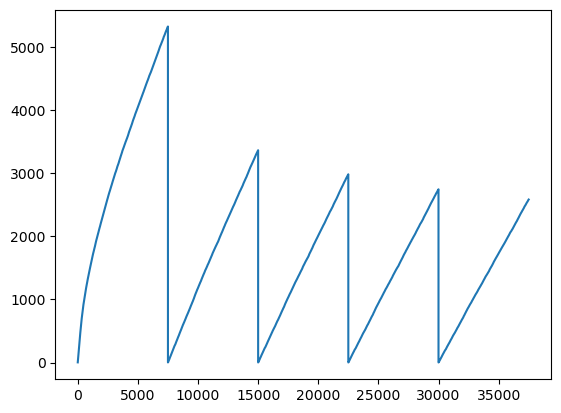

In [22]:
print(loss_history)
plt.plot(loss_history)
plt.show()

In [ ]:
class dropANN(nn.Module):
        def __init__(self):
            super(dropANN, self).__init__()

            self.flatten = nn.Flatten()
            self.fc1 = nn.Linear(784, 128)
            self.dropout = nn.Dropout(p=0.5)
            self.fc2 = nn.Linear(128, 64)
            self.dropout = nn.Dropout(p=0.5)
            self.fc3 = nn.Linear(64, 10)

        def forward(self, x):
            x = self.flatten(x)  
            x = F.relu(self.fc1(x))
            x = self.dropout(x)
            x = F.relu(self.fc2(x))
            x = self.dropout(x)
            x = self.fc3(x)
            return x

In [10]:
model = dropANN()
criterion = nn.CrossEntropyLoss()
learning_rate = 0.01
for epoch in range(5):

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Manual Gradient Descent
        with torch.no_grad():
            for param in model.parameters():
                param -= learning_rate * param.grad

        # Zero gradients
        model.zero_grad()

        # Accumulate loss
        total_loss += loss.item()

        # Compute accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Compute average loss
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

AttributeError: 'dropANN' object has no attribute 'drop1'